In [1]:
import uproot
import pandas as pd
import numpy as np
import glob


In [2]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [3]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250216_CMS_Psum"
# cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
#                "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]
cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/new_FOM/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [5]:
len(file_list)

0

In [4]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


ValueError: No objects to concatenate

In [6]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,279993.000000,279993.000000,279993.000000,279993.000000,279993.000000
mean,1.757398,0.101509,0.363407,1.588655,-0.003325
std,0.154709,0.489838,0.499846,0.867577,0.999996
min,1.500001,-0.999612,-0.903704,0.400001,-1.000000
25%,1.628803,-0.305091,-0.011536,0.850233,-1.000000
50%,1.738797,0.123059,0.493308,1.467459,-1.000000
75%,1.876754,0.522094,0.806737,2.175200,1.000000
max,2.099998,0.999989,0.978369,5.847296,1.000000


In [7]:
df_proc13 = df_proc13.query('Dp_M> 1.7 & Dp_M<2.1')


In [8]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,164822.000000,164822.000000,164822.000000,164822.000000,164822.000000
mean,1.863869,0.094066,0.367727,1.606224,-0.006091
std,0.103917,0.489066,0.501684,0.896523,0.999984
min,1.700001,-0.999567,-0.903704,0.400001,-1.000000
25%,1.765335,-0.310249,-0.010957,0.841047,-1.000000
50%,1.866693,0.108271,0.502544,1.477802,-1.000000
75%,1.964023,0.511145,0.813968,2.207114,1.000000
max,2.099998,0.999989,0.978369,5.847296,1.000000


In [9]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [10]:
import glob

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_noD0"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p"

cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    # pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"
    pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/skimhad/new_FOM/*.BCS.root"


    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [11]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [12]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,953117.000000,953117.000000,953117.000000,953117.000000,953117.000000
mean,1.753651,0.084056,0.332330,1.597274,-0.000652
std,0.153469,0.492049,0.492434,0.832349,1.000000
min,1.500002,-0.999983,-0.905708,0.400001,-1.000000
25%,1.626413,-0.325435,-0.044193,0.906289,-1.000000
50%,1.732687,0.103195,0.438209,1.482587,-1.000000
75%,1.875306,0.506881,0.768433,2.150967,1.000000
max,2.099997,0.999975,0.979527,6.012280,1.000000


In [13]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.7 & Dp_M<2.1')


In [14]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,550599.000000,550599.000000,550599.000000,550599.000000,550599.000000
mean,1.861970,0.079122,0.334097,1.621090,0.000521
std,0.102825,0.491202,0.493820,0.856294,1.000001
min,1.700000,-0.999983,-0.905708,0.400010,-1.000000
25%,1.762958,-0.327415,-0.046866,0.910859,-1.000000
50%,1.866706,0.093055,0.442576,1.504883,1.000000
75%,1.964560,0.497994,0.773327,2.185829,1.000000
max,2.099997,0.999975,0.979527,6.012280,1.000000


In [15]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [16]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


/home/jykim/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3378: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  exec(code_obj, self.user_global_ns, self.user_ns)


In [17]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


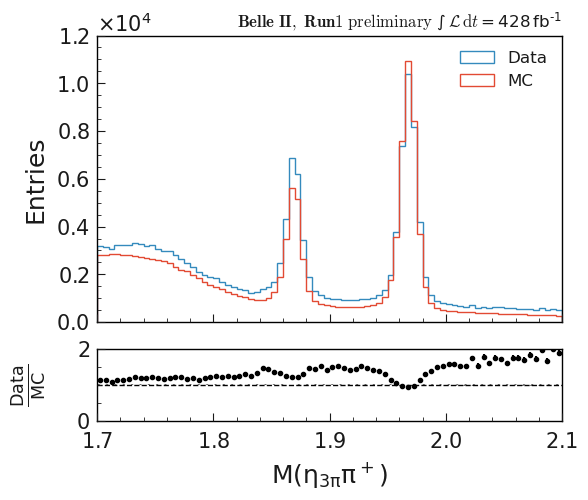

In [19]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{3\pi} \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.7,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_new_FOM.png", bbox_inches="tight")

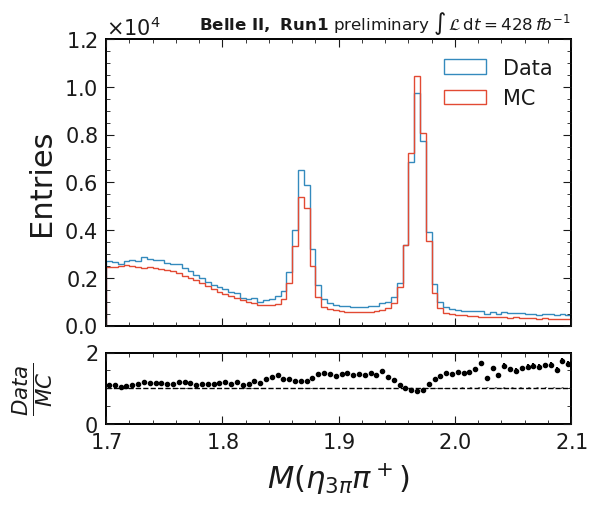

In [109]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{3\pi} \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.7,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}.png", bbox_inches="tight")